In [3]:
# ==========================================================
# Step 1
# Load the Final Processed Dataset
# ==========================================================

# Tech Stack:
# Pandas -> Used for loading and handling tabular datasets.

import pandas as pd

# Load the processed dataset created during Week 3.
#
# This dataset already contains:
# • Cleaned task descriptions
# • TF-IDF features
# • Encoded categorical variables
# • Numerical engineered features
# • AI Exposure Score (Target Variable)

df = pd.read_csv("../data/processed/task_ai_exposure.csv")

# Display first five records
df.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,SOC Code,Occupation Title,AIOE
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334


In [4]:

# Check dataset dimensions
# Rows = Number of task samples
# Columns = Features + Target Variable

print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns Available:\n")
print(df.columns.tolist())

Dataset Shape: (15814, 11)

Columns Available:

['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source', 'SOC Code', 'Occupation Title', 'AIOE']


In [5]:
# ----------------------------------------------------------
# Machine Learning models cannot handle missing values.
# Verify that the dataset is completely clean before training.
# ----------------------------------------------------------

missing = df.isnull().sum()

print("Missing Values:\n")
print(missing[missing > 0])

Missing Values:

Task Type                254
Incumbents Responding    495
dtype: int64


In [6]:
# ==========================================================
# Week 4 - Step 2
# Load Feature Matrix (X) and Target Variable (y)
# ==========================================================

# Tech Stack:
# Joblib -> Efficient serialization library for storing
# large NumPy arrays, sparse matrices, and ML objects.

import joblib

# ----------------------------------------------------------
# Load Feature Matrix (X)
# Created during Week 3 Feature Engineering.
#
# X contains:
# • TF-IDF text features
# • Encoded categorical features
# • Numerical engineered features
# ----------------------------------------------------------

X = joblib.load("../data/processed/X_features.pkl")

# ----------------------------------------------------------
# Load Target Variable (y)
# AI Exposure Score that the model will learn to predict.
# ----------------------------------------------------------

y = joblib.load("../data/processed/y_target.pkl")

In [7]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

print("\nFeature Matrix Type:")
print(type(X))

Feature Matrix Shape : (15814, 1004)
Target Shape         : (15814,)

Feature Matrix Type:
<class 'scipy.sparse._coo.coo_matrix'>


In [8]:
print(y[:10])

0    1.334
1    1.334
2    1.334
3    1.334
4    1.334
5    1.334
6    1.334
7    1.334
8    1.334
9    1.334
Name: AIOE, dtype: float64


In [9]:
# ==========================================================
# Week 4 - Step 3
# Split Dataset into Training and Testing Sets
# ==========================================================

# Tech Stack:
# Scikit-learn -> Provides machine learning utilities.
# train_test_split() -> Splits data for training and evaluation.

from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Split the dataset
#
# X -> Feature Matrix
# y -> Target Variable
#
# test_size = 0.20
#     Reserve 20% of the data for testing.
#
# random_state = 42
#     Ensures the split is reproducible.
#
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
# ----------------------------------------------------------
# Display the size of each dataset.
# ----------------------------------------------------------

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("\nTraining Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (12651, 1004)
Testing Features  : (3163, 1004)

Training Target : (12651,)
Testing Target  : (3163,)


In [11]:
# ----------------------------------------------------------
# Calculate the percentage of samples in each split.
# ----------------------------------------------------------

total_samples = len(y)

train_percentage = (len(y_train) / total_samples) * 100
test_percentage = (len(y_test) / total_samples) * 100

print(f"Training Data : {train_percentage:.2f}%")
print(f"Testing Data  : {test_percentage:.2f}%")

Training Data : 80.00%
Testing Data  : 20.00%


In [12]:
# ==========================================================
# Week 4 - Step 4
# Train Baseline Linear Regression Model
# ==========================================================

# Tech Stack:
# Scikit-learn -> Machine Learning library
# LinearRegression -> Baseline regression model

from sklearn.linear_model import LinearRegression

# ----------------------------------------------------------
# Create the Linear Regression model.
#
# At this stage, the model has not learned anything.
# ----------------------------------------------------------

linear_model = LinearRegression()

# ----------------------------------------------------------
# Train the model using the training dataset.
#
# During training, the algorithm learns the relationship
# between the feature matrix (X_train) and the target
# variable (y_train).
# ----------------------------------------------------------

linear_model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")

✅ Linear Regression model trained successfully!


In [13]:
# ----------------------------------------------------------
# Display the learned coefficients.
#
# Each coefficient represents the influence of a feature
# on the predicted AI Exposure Score.
#
# Since TF-IDF creates hundreds of features,
# only the number of coefficients is displayed.
# ----------------------------------------------------------

print("Number of Learned Coefficients:")
print(len(linear_model.coef_))

print("\nIntercept:")
print(linear_model.intercept_)

Number of Learned Coefficients:
1004

Intercept:
-0.2577192275714286


In [14]:
# ----------------------------------------------------------
# Predict AI Exposure Scores for the testing dataset.
#
# These predictions will be compared with the actual values
# in the next step to evaluate model performance.
# ----------------------------------------------------------

y_pred_lr = linear_model.predict(X_test)

print("First 10 Predictions:\n")
print(y_pred_lr[:10])

First 10 Predictions:

[ 0.17877041  1.33345541  1.07743344  1.06158113  0.61447423  0.18561751
 -0.10354663  0.18724574  1.13798575  0.18807551]


In [15]:
# ==========================================================
# Week 4 - Step 5
# Evaluate the Linear Regression Model
# ==========================================================

# Tech Stack:
# Scikit-learn -> Regression evaluation metrics
# NumPy -> Mathematical operations

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ----------------------------------------------------------
# Calculate evaluation metrics
# ----------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

In [16]:
# ----------------------------------------------------------
# Print model performance metrics
# ----------------------------------------------------------

print("=" * 50)
print("Linear Regression Performance")
print("=" * 50)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance
Mean Absolute Error (MAE): 0.4813
Mean Squared Error (MSE): 0.3828
Root Mean Squared Error (RMSE): 0.6187
R² Score: 0.5962


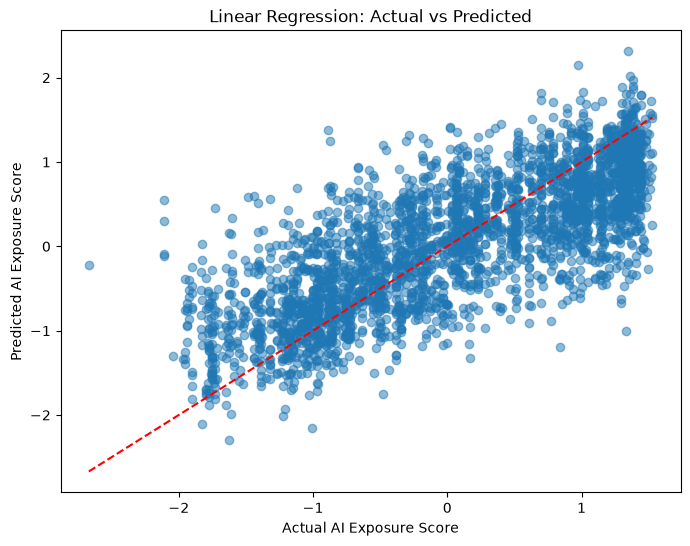

In [17]:
# ==========================================================
# Visualize Actual vs Predicted Values
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual AI Exposure Score")
plt.ylabel("Predicted AI Exposure Score")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [18]:
# ==========================================================
# Week 4 - Step 6
# Train Random Forest Regressor
# ==========================================================

# Tech Stack:
# Scikit-learn -> Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# ----------------------------------------------------------
# Create the Random Forest model.
#
# n_estimators = Number of decision trees.
# random_state = Ensures reproducible results.
# n_jobs = -1 uses all available CPU cores.
# ----------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# ----------------------------------------------------------
# Train the model using the training dataset.
# ----------------------------------------------------------

rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [19]:
# ----------------------------------------------------------
# Predict AI Exposure Scores using the Random Forest model.
# ----------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)

In [20]:
# ----------------------------------------------------------
# Calculate evaluation metrics for Random Forest.
# ----------------------------------------------------------

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("=" * 50)
print("Random Forest Performance")
print("=" * 50)

print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
MAE  : 0.4615
MSE  : 0.3873
RMSE : 0.6223
R²   : 0.5914


In [21]:
# ==========================================================
# Compare Linear Regression and Random Forest
# ==========================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.481341,0.618680,0.596176
1,Random Forest,0.461468,0.622326,0.591402


In [23]:
print(type(X_train))

<class 'scipy.sparse._csr.csr_matrix'>


In [24]:
# ==========================================================
# Week 4 - Step 7
# Load TF-IDF Vectorizer
# ==========================================================

# Tech Stack:
# Joblib -> Load saved preprocessing objects

import joblib

# Load the TF-IDF vectorizer created during Week 3
tfidf_vectorizer = joblib.load("../data/processed/tfidf_vectorizer.pkl")

In [25]:
# ----------------------------------------------------------
# Retrieve the vocabulary (feature names) learned by
# the TF-IDF vectorizer.
# ----------------------------------------------------------

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Total TF-IDF Features:", len(feature_names))

Total TF-IDF Features: 1000


In [28]:
print("TF-IDF Features :", len(feature_names))
print("Model Features  :", len(rf_model.feature_importances_))

TF-IDF Features : 1000
Model Features  : 1004


In [29]:
# ==========================================================
# Combine TF-IDF feature names with engineered features
# ==========================================================

# These are the additional features added after TF-IDF
engineered_features = [
    "task_length",
    "word_count",
    "task_type_encoded",
    "complexity_score"
]

# Combine feature names
all_feature_names = list(feature_names) + engineered_features

print("Total Feature Names :", len(all_feature_names))
print("Model Features      :", len(rf_model.feature_importances_))

Total Feature Names : 1004
Model Features      : 1004


In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1003,complexity_score,0.183489
961,using,0.051134
881,students,0.023405
777,research,0.019977
526,machines,0.015692
880,student,0.013239
248,develop,0.009826
447,information,0.009123
312,equipment,0.008569
785,review,0.008350


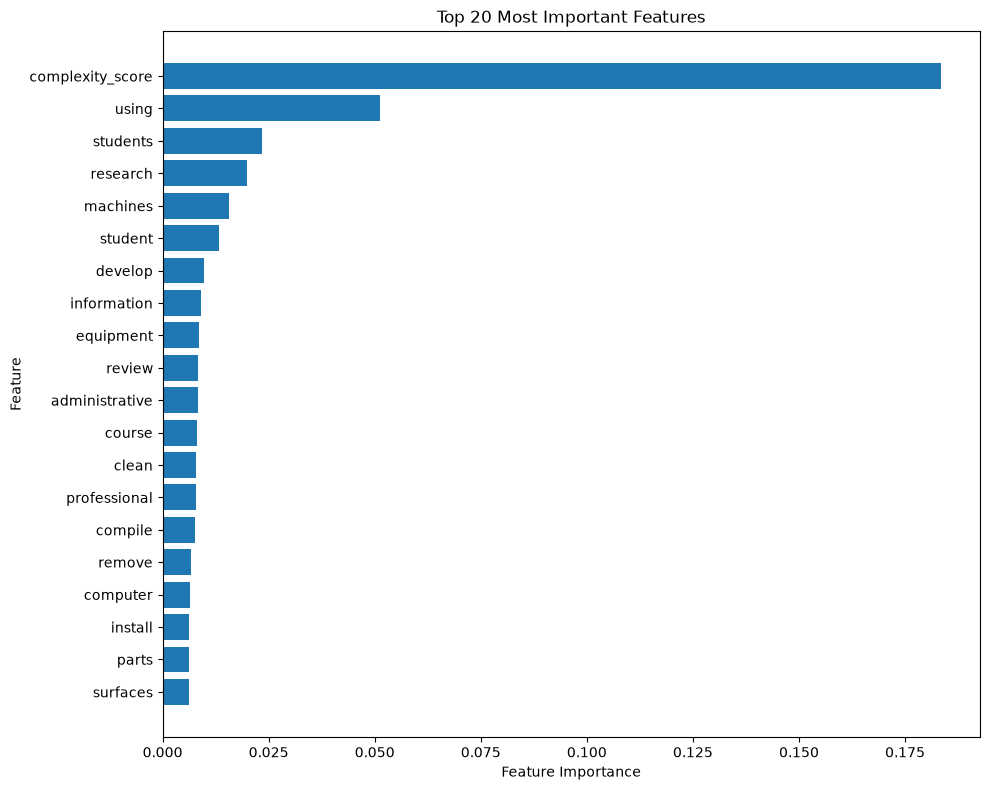

In [31]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [32]:
# ==========================================================
# Week 4 - Step 8
# Save Best Model
# ==========================================================

# Tech Stack:
# Joblib -> Serialize trained machine learning models

import joblib

# ----------------------------------------------------------
# Save the trained Random Forest model
# ----------------------------------------------------------

joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [33]:
# ----------------------------------------------------------
# Load the saved model to verify it was stored correctly.
# ----------------------------------------------------------

loaded_model = joblib.load("../models/random_forest_model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [34]:
# ----------------------------------------------------------
# Use the loaded model to make predictions.
# This confirms that the saved model works correctly.
# ----------------------------------------------------------

sample_prediction = loaded_model.predict(X_test[:5])

print("Predicted AI Exposure Scores:")
print(sample_prediction)

Predicted AI Exposure Scores:
[-0.03794   1.28797   0.4497    1.330755  0.69466 ]
